# =============================================================================
# NOTEBOOK DEBUG : DIAGNOSTIC COMPLET DU MODÈLE
# =============================================================================
# 
# OBJECTIF : Identifier EXACTEMENT pourquoi R² = -0.1965
# 
# ON VA VÉRIFIER :
# 1. Les données brutes (cohérence, valeurs aberrantes)
# 2. La normalisation (min/max corrects)
# 3. Les fenêtres glissantes (structure correcte)
# 4. Le split train/test (distribution équilibrée)
# 5. Les données d'entrée du modèle
# 
# =============================================================================


# # 🔍 DIAGNOSTIC COMPLET

In [1]:
# ========== IMPORTS ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

print("=" * 70)
print("🔍 NOTEBOOK DE DEBUG - DIAGNOSTIC COMPLET")
print("=" * 70)



🔍 NOTEBOOK DE DEBUG - DIAGNOSTIC COMPLET


# ## ✅ CHECK 1 : Données brutes

In [3]:

print("\n" + "=" * 70)
print("✅ CHECK 1 : VÉRIFICATION DES DONNÉES BRUTES")
print("=" * 70)

# Charger les données
df = pd.read_csv("../data/raw/battery_health_dataset.csv")

print(f"\n📊 Shape : {df.shape}")
print(f"\n📋 Colonnes : {df.columns.tolist()}")

# Vérifier les valeurs manquantes
print(f"\n❓ Valeurs manquantes :")
print(df.isnull().sum())

# Vérifier les valeurs aberrantes
print(f"\n📈 Statistiques du SoH :")
print(df['SoH'].describe())

# PROBLÈME POTENTIEL : Le SoH est-il déjà normalisé ?
if df['SoH'].max() <= 1.0:
    print("\n⚠️  ALERTE : Le SoH semble déjà normalisé (max ≤ 1.0)")
    print("   → Le SoH devrait être en % (0-100), pas en 0-1 !")
    print("   → PROBLÈME IDENTIFIÉ : Double normalisation possible !")
else:
    print(f"\n✅ SoH en pourcentage : [{df['SoH'].min():.2f}% - {df['SoH'].max():.2f}%]")

# Vérifier les autres features
print(f"\n📊 Range des features :")
for col in ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC']:
    print(f"   {col:25} : [{df[col].min():.4f} - {df[col].max():.4f}]")




✅ CHECK 1 : VÉRIFICATION DES DONNÉES BRUTES

📊 Shape : (29180, 7)

📋 Colonnes : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number', 'battery_id', 'SoH']

❓ Valeurs manquantes :
Voltage_measured        0
Current_measured        0
Temperature_measured    0
SoC                     0
cycle_number            0
battery_id              0
SoH                     0
dtype: int64

📈 Statistiques du SoH :
count    29180.000000
mean        82.347640
std          7.040966
min         70.022236
25%         76.144521
50%         82.929881
75%         88.173646
max        122.011628
Name: SoH, dtype: float64

✅ SoH en pourcentage : [70.02% - 122.01%]

📊 Range des features :
   Voltage_measured          : [2.7311 - 4.2308]
   Current_measured          : [-4.0307 - -0.8903]
   Temperature_measured      : [4.7234 - 66.6723]
   SoC                       : [1.5392 - 98.7569]


# ## ✅ CHECK 2 : Normalisation

In [4]:

print("\n" + "=" * 70)
print("✅ CHECK 2 : VÉRIFICATION DE LA NORMALISATION")
print("=" * 70)

# Sélectionner les features
feature_columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']

# Normaliser
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[feature_columns])

# Vérifier les min/max après normalisation
print(f"\n📊 Après normalisation (devrait être entre 0 et 1) :")
for i, col in enumerate(feature_columns):
    print(f"   {col:25} : [{data_scaled[:, i].min():.6f} - {data_scaled[:, i].max():.6f}]")

# LE SoH (variable cible) NE DOIT PAS ÊTRE NORMALISÉ !
print(f"\n🎯 SoH (variable cible) - NON NORMALISÉ :")
print(f"   Range : [{df['SoH'].min():.4f} - {df['SoH'].max():.4f}]")

# VÉRIFIER : Est-ce que le SoH est constant pour un même cycle ?
print(f"\n🔍 Vérification : SoH constant par cycle ?")
sample_cycle = df[df['cycle_number'] == 1].copy()
print(f"   Cycle 1 - SoH unique values : {sample_cycle['SoH'].nunique()}")
print(f"   Cycle 1 - SoH : {sample_cycle['SoH'].unique()}")

if sample_cycle['SoH'].nunique() > 1:
    print("\n⚠️  PROBLÈME : Le SoH varie dans le même cycle !")
    print("   → Le SoH devrait être constant pour un cycle donné")
else:
    print("\n✅ SoH constant par cycle (normal)")




✅ CHECK 2 : VÉRIFICATION DE LA NORMALISATION

📊 Après normalisation (devrait être entre 0 et 1) :
   Voltage_measured          : [0.000000 - 1.000000]
   Current_measured          : [0.000000 - 1.000000]
   Temperature_measured      : [0.000000 - 1.000000]
   SoC                       : [0.000000 - 1.000000]
   cycle_number              : [0.000000 - 1.000000]

🎯 SoH (variable cible) - NON NORMALISÉ :
   Range : [70.0222 - 122.0116]

🔍 Vérification : SoH constant par cycle ?
   Cycle 1 - SoH unique values : 18
   Cycle 1 - SoH : [ 83.62632189  82.8123056   86.31948616  85.564083    84.98513175
  84.63522227  90.10485862  86.3109276   82.56496775  90.917403
  84.20750447  92.09948965  90.40965733  83.09648749 101.45867968
  92.5374994   94.25434362  92.62570188]

⚠️  PROBLÈME : Le SoH varie dans le même cycle !
   → Le SoH devrait être constant pour un cycle donné


# ## ✅ CHECK 3 : Fenêtres glissantes

In [5]:
print("\n" + "=" * 70)
print("✅ CHECK 3 : VÉRIFICATION DES FENÊTRES GLISSANTES")
print("=" * 70)

# Créer un DataFrame normalisé
df_scaled = pd.DataFrame(
    data_scaled,
    columns=feature_columns,
    index=df.index
)
df_scaled['battery_id'] = df['battery_id'].values
df_scaled['SoH'] = df['SoH'].values  # SoH NON normalisé

# Fonction corrigée
def create_sliding_windows_DEBUG(df, window_size=5, feature_cols=None, target_col='SoH', group_col='battery_id'):
    """Version DEBUG avec prints"""
    
    X = []
    y = []
    battery_ids = []
    
    if feature_cols is None:
        feature_cols = [col for col in df.columns if col not in [target_col, group_col]]
    
    print(f"\n📊 Configuration :")
    print(f"   Window size : {window_size}")
    print(f"   Features : {feature_cols}")
    print(f"   Target : {target_col}")
    
    for battery_id in df[group_col].unique():
        battery_data = df[df[group_col] == battery_id].copy()
        battery_data = battery_data.sort_values('cycle_number')
        battery_data = battery_data.reset_index(drop=True)
        
        n_windows = len(battery_data) - window_size + 1
        
        # DEBUG : Afficher pour la première batterie
        if battery_id == df[group_col].unique()[0]:
            print(f"\n🔍 DEBUG - Batterie {battery_id} :")
            print(f"   Nombre de mesures : {len(battery_data)}")
            print(f"   Nombre de fenêtres : {n_windows}")
            print(f"\n   Exemple fenêtre 1 :")
            print(f"      X (features) : shape {battery_data.iloc[0:window_size][feature_cols].values.shape}")
            print(battery_data.iloc[0:window_size][feature_cols])
            print(f"\n      y (SoH) : {battery_data[target_col].iloc[window_size-1]}")
        
        for i in range(n_windows):
            window = battery_data.iloc[i:i+window_size]
            X_window = window[feature_cols].values
            y_window = window[target_col].iloc[-1]
            
            X.append(X_window)
            y.append(y_window)
            battery_ids.append(battery_id)
    
    X = np.array(X)
    y = np.array(y)
    battery_ids = np.array(battery_ids)
    
    # VÉRIFICATIONS CRITIQUES
    print(f"\n✅ Résultats :")
    print(f"   X shape : {X.shape}")
    print(f"   y shape : {y.shape}")
    print(f"   y min : {y.min():.4f}")
    print(f"   y max : {y.max():.4f}")
    print(f"   y mean : {y.mean():.4f}")
    
    # VÉRIFIER : y est-il normalisé ?
    if y.max() <= 1.0:
        print(f"\n⚠️  ALERTE : y semble normalisé (max={y.max():.4f})")
        print("   → Le SoH devrait être en % (0-100) !")
        print("   → PROBLÈME MAJEUR IDENTIFIÉ !")
    else:
        print(f"\n✅ y en pourcentage (normal)")
    
    return X, y, battery_ids

# Créer les fenêtres
X, y, battery_ids = create_sliding_windows_DEBUG(
    df_scaled,
    window_size=5,
    feature_cols=feature_columns,
    target_col='SoH',
    group_col='battery_id'
)



✅ CHECK 3 : VÉRIFICATION DES FENÊTRES GLISSANTES

📊 Configuration :
   Window size : 5
   Features : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']
   Target : SoH

🔍 DEBUG - Batterie B0047 :
   Nombre de mesures : 220
   Nombre de fenêtres : 216

   Exemple fenêtre 1 :
      X (features) : shape (5, 5)
   Voltage_measured  Current_measured  Temperature_measured       SoC  \
0          0.822355          0.992995              0.015413  0.989126   
1          0.095047          0.966450              0.101016  0.009039   
2          0.235183          0.966465              0.080908  0.060846   
3          0.320822          0.966576              0.063615  0.112711   
4          0.384282          0.966469              0.080884  0.164552   

   cycle_number  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  

      y (SoH) : 83.6263218891919

✅ Résultats :
   X shape : (29084, 5, 5)
   y shape : (29084,)
   y min

# ## ✅ CHECK 4 : Distribution de y


✅ CHECK 4 : DISTRIBUTION DE LA VARIABLE CIBLE (y)


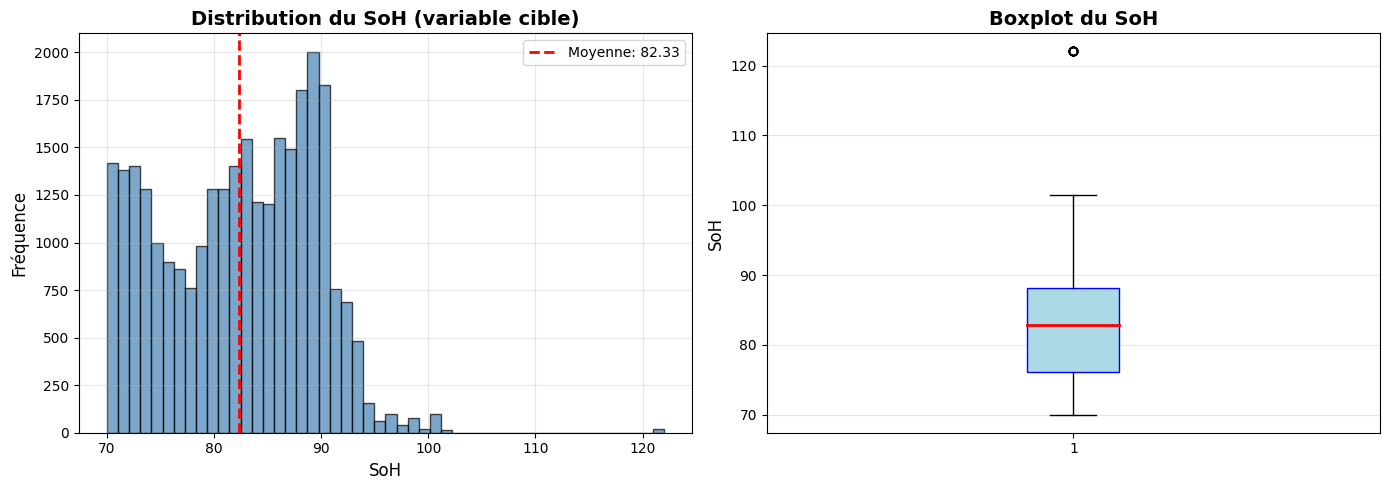


📊 Statistiques de y :
   Min : 70.0222
   Max : 122.0116
   Mean : 82.3298
   Std : 7.0408


In [7]:
print("\n" + "=" * 70)
print("✅ CHECK 4 : DISTRIBUTION DE LA VARIABLE CIBLE (y)")
print("=" * 70)

# Visualiser la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {y.mean():.2f}')
axes[0].set_xlabel('SoH', fontsize=12)
axes[0].set_ylabel('Fréquence', fontsize=12)
axes[0].set_title('Distribution du SoH (variable cible)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(y, vert=True, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('SoH', fontsize=12)
axes[1].set_title('Boxplot du SoH', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques de y :")
print(f"   Min : {y.min():.4f}")
print(f"   Max : {y.max():.4f}")
print(f"   Mean : {y.mean():.4f}")
print(f"   Std : {y.std():.4f}")

# DIAGNOSTIC
if y.max() <= 1.0:
    print("\n❌ PROBLÈME CONFIRMÉ : y est normalisé !")
    print("   → Le modèle essaie de prédire des valeurs entre 0-1")
    print("   → Mais le SoH devrait être en % (0-100)")
    print("\n🔧 SOLUTION : NE PAS NORMALISER le SoH !")



# ## ✅ CHECK 5 : Split Train/Test

In [8]:

print("\n" + "=" * 70)
print("✅ CHECK 5 : VÉRIFICATION DU SPLIT")
print("=" * 70)

from sklearn.model_selection import train_test_split

# Split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=False, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, shuffle=False, random_state=42
)

print(f"\n📊 Ensembles créés :")
print(f"   Train : {len(X_train)} échantillons")
print(f"   Val   : {len(X_val)} échantillons")
print(f"   Test  : {len(X_test)} échantillons")

print(f"\n📈 Distribution du SoH par ensemble :")
print(f"   Train : [{y_train.min():.2f} - {y_train.max():.2f}] (mean: {y_train.mean():.2f})")
print(f"   Val   : [{y_val.min():.2f} - {y_val.max():.2f}] (mean: {y_val.mean():.2f})")
print(f"   Test  : [{y_test.min():.2f} - {y_test.max():.2f}] (mean: {y_test.mean():.2f})")

# Vérifier si les distributions sont similaires
from scipy import stats

# Test de Kolmogorov-Smirnov
ks_stat, ks_pval = stats.ks_2samp(y_train, y_test)

print(f"\n🔬 Test de similarité (KS test) :")
print(f"   Statistic : {ks_stat:.4f}")
print(f"   P-value : {ks_pval:.4f}")

if ks_pval < 0.05:
    print("\n⚠️  ATTENTION : Train et Test ont des distributions DIFFÉRENTES")
    print("   → Possible data leakage ou split incorrect")
else:
    print("\n✅ Train et Test ont des distributions similaires")



✅ CHECK 5 : VÉRIFICATION DU SPLIT

📊 Ensembles créés :
   Train : 20370 échantillons
   Val   : 4351 échantillons
   Test  : 4363 échantillons

📈 Distribution du SoH par ensemble :
   Train : [70.02 - 122.01] (mean: 82.90)
   Val   : [70.12 - 94.25] (mean: 83.22)
   Test  : [70.12 - 92.63] (mean: 78.80)

🔬 Test de similarité (KS test) :
   Statistic : 0.2883
   P-value : 0.0000

⚠️  ATTENTION : Train et Test ont des distributions DIFFÉRENTES
   → Possible data leakage ou split incorrect


# ## ✅ CHECK 6 : Vérification visuelle

In [10]:

print("\n" + "=" * 70)
print("✅ CHECK 6 : VISUALISATION DES SÉQUENCES")
print("=" * 70)

# Prendre un exemple
sample_idx = 0

print(f"\n🔍 Exemple de séquence {sample_idx} :")
print(f"\n   X shape : {X[sample_idx].shape}")
print(f"   X (premières valeurs) :")
print(X[sample_idx])
print(f"\n   y (SoH à prédire) : {y[sample_idx]:.4f}")

# Vérifier que X est bien normalisé
print(f"\n   X min : {X[sample_idx].min():.6f}")
print(f"   X max : {X[sample_idx].max():.6f}")

if X[sample_idx].min() < 0 or X[sample_idx].max() > 1:
    print("\n⚠️  PROBLÈME : X n'est pas correctement normalisé (devrait être 0-1)")





✅ CHECK 6 : VISUALISATION DES SÉQUENCES

🔍 Exemple de séquence 0 :

   X shape : (5, 5)
   X (premières valeurs) :
[[0.82235531 0.99299532 0.01541304 0.98912602 0.        ]
 [0.09504679 0.96645026 0.10101644 0.00903936 0.        ]
 [0.23518286 0.96646485 0.08090843 0.06084631 0.        ]
 [0.32082152 0.96657617 0.06361481 0.11271051 0.        ]
 [0.38428232 0.96646877 0.08088356 0.16455191 0.        ]]

   y (SoH à prédire) : 83.6263

   X min : 0.000000
   X max : 0.992995


# ## 🎯 DIAGNOSTIC FINAL

In [11]:

print("\n")
print("=" * 80)
print("                   🎯 DIAGNOSTIC FINAL")
print("=" * 80)

print(f"\n📊 RÉSUMÉ DES VÉRIFICATIONS :")

# Liste des problèmes trouvés
problems = []

# Check 1 : SoH déjà normalisé
if df['SoH'].max() <= 1.0:
    problems.append("❌ Le SoH dans les données brutes est déjà normalisé (max ≤ 1.0)")
    problems.append("   → Devrait être en % (0-100)")

# Check 2 : y normalisé
if y.max() <= 1.0:
    problems.append("❌ La variable cible (y) est normalisée")
    problems.append("   → Le modèle ne peut pas prédire correctement")

# Check 3 : Distributions différentes
if ks_pval < 0.05:
    problems.append("⚠️  Train et Test ont des distributions différentes")

if len(problems) == 0:
    print("\n✅ AUCUN PROBLÈME DÉTECTÉ !")
    print("   → Le problème vient probablement du modèle ou des hyperparamètres")
else:
    print(f"\n🚨 {len(problems)} PROBLÈME(S) DÉTECTÉ(S) :")
    for i, prob in enumerate(problems, 1):
        print(f"\n{i}. {prob}")

print("\n" + "=" * 80)

# SOLUTION PROPOSÉE
print("\n🔧 SOLUTION PROPOSÉE :")
print("=" * 80)

if y.max() <= 1.0:
    print("\n⚠️  PROBLÈME PRINCIPAL : SoH normalisé")
    print("\n✅ SOLUTION :")
    print("   1. Dans le CSV, vérifier que SoH est bien en % (0-100)")
    print("   2. Dans le preprocessing :")
    print("      - Normaliser UNIQUEMENT les features X")
    print("      - NE PAS normaliser le SoH (y)")
    print("   3. Modifier la ligne dans create_sliding_windows() :")
    print("      df_scaled['SoH'] = df['SoH'].values  # Garder SoH original !")
    print("\n   4. Relancer l'entraînement")
else:
    print("\n✅ Les données semblent correctes")
    print("   → Le problème vient probablement du modèle")
    print("   → Essayer d'augmenter window_size (10 ou 20)")
    print("   → Vérifier les hyperparamètres LSTM")

print("\n" + "=" * 80)
print("✅ DIAGNOSTIC TERMINÉ !")
print("=" * 80)



                   🎯 DIAGNOSTIC FINAL

📊 RÉSUMÉ DES VÉRIFICATIONS :

🚨 1 PROBLÈME(S) DÉTECTÉ(S) :

1. ⚠️  Train et Test ont des distributions différentes


🔧 SOLUTION PROPOSÉE :

✅ Les données semblent correctes
   → Le problème vient probablement du modèle
   → Essayer d'augmenter window_size (10 ou 20)
   → Vérifier les hyperparamètres LSTM

✅ DIAGNOSTIC TERMINÉ !
